# LLM Forward Model Implementation

In [1]:
# Import the libraries we need
import torch
from torch import nn
from torch.nn import functional as F
import random
import math
import re
import pickle
import time
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from utils import character_level_tokenizer, PositionalEncoding, get_batch, pad_token, eos_token

# set a fixed seed for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

## Tokenizer

Our complete set of tokens is:  
`{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, +, -, =, [PAD], [EOS]}`  


Note that since our digits are 0–9, the token IDs for the other symbols follow sequentially:  
- `+` is assigned token ID **10**
- `-` is assigned token ID **11**
- `=` is assigned token ID **12**
- `[PAD]`is assigned token ID **13**
- `[EOS]`is assigned token ID **14**


We assign a unique number to each token and build a **tokenizer**—a class that converts a string of characters into a list of tokens.

In [2]:
# create the tokenizer and check the vocabulary
tokenizer = character_level_tokenizer()
print(f"Vocabulary ({tokenizer.ntokens} tokens):", tokenizer.vocab)

# test encoding and decoding for addition
sample_eq_1 = "123+32=" + str(123 + 32)
encoded_1 = tokenizer.encode(sample_eq_1)
print(f"\nTokenized '{sample_eq_1}':", encoded_1)
print(f"Decoded from token IDs: {tokenizer.decode(encoded_1)}")

# test encoding and decoding for subtraction
sample_eq_2 = "99-17=" + str(99 - 17)
encoded_2 = tokenizer.encode(sample_eq_2)
print(f"\nTokenized '{sample_eq_2}':", encoded_2)
print(f"Decoded from token IDs: {tokenizer.decode(encoded_2)}")

Vocabulary (15 tokens): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '-', '=', '[PAD]', '[EOS]']

Tokenized '123+32=155': [1, 2, 3, 10, 3, 2, 12, 1, 5, 5]
Decoded from token IDs: 123+32=155

Tokenized '99-17=82': [9, 9, 11, 1, 7, 12, 8, 2]
Decoded from token IDs: 99-17=82


## Dataset Generation

Prompts are left-padded to align the `=` sign for generation, while answers are right-padded with an `[EOS]` token appended at the end.

In [3]:
# generate and save the shared dataset
%run generate_data.py


Train: 100,000
Addition:    50,000 (50.0%)
Subtraction: 50,000 (50.0%)

Val: 20,000
Addition:    10,000 (50.0%)
Subtraction: 10,000 (50.0%)

Test: 20,000
Addition:    10,000 (50.0%)
Subtraction: 10,000 (50.0%)

Train overlap Val: 0
Train overlap Test: 0
Val overlap Test: 0

Dataset saved to assets/dataset.pkl


In [4]:
# check one sample from each operation
print("Addition sample:", next(x for x in data_train if "+" in x[0]))
print("Subtraction sample:", next(x for x in data_train if "-" in x[0]))

Addition sample: ('997+123=', '1120')
Subtraction sample: ('484-14=', '470')


In [5]:
# load the shared dataset
with open("assets/dataset.pkl", "rb") as f:
    dataset = pickle.load(f)

# get the training, validation, and test sets
data_train = dataset["train"]
data_val = dataset["val"]
data_test = dataset["test"]

# check the dataset sizes
print(f'Train: {len(data_train)}, Val: {len(data_val)}, Test: {len(data_test)}')

Train: 100000, Val: 20000, Test: 20000


## Positional Encoding

Positional encoding is required so the Transformer can distinguish the order of tokens.   
The implementation is defined in `utils.py` and applied within the Transformer model architecture.  

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


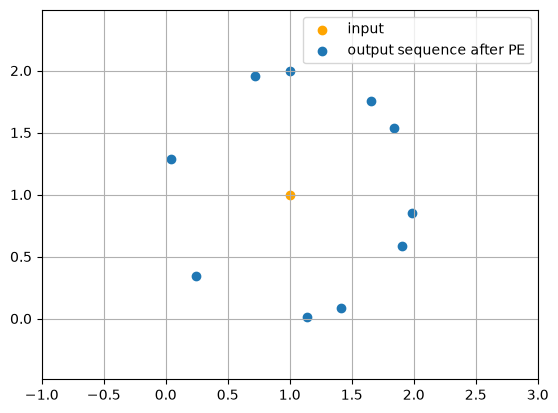

In [6]:
# visualize positional encoding in 2D
PE = PositionalEncoding(d_model=2, dropout=0)
x = torch.ones((10,1,2))
y = PE(x)

# plot the input and positional encoding output
plt.scatter(1,1,c='orange',label='input')
plt.scatter(y[:,0,0],y[:,0,1],label='output sequence after PE')
plt.axis('equal')
plt.xlim((-1,3))
plt.ylim((-1,3))
plt.grid('on')
plt.legend()
plt.show()

## Transformer Model Architecture

The Transformer model uses token embeddings, positional encoding, and a causal attention mask to predict the next token

In [7]:
class CustomEncoderLayer(nn.TransformerEncoderLayer):
    def __init__(self,*args,**kwargs):
        super().__init__(*args,**kwargs)
        # store the attention weights
        self.attn_weights = None

    def forward(self,src,src_mask=None,src_key_padding_mask=None,is_causal=False):
        # calculate self-attention
        src2,attn_weights = self.self_attn(
            src,src,src,
            attn_mask=src_mask,
            key_padding_mask=src_key_padding_mask,
            need_weights=True,
            average_attn_weights=False,
            is_causal=is_causal
        )
        # store the attention weights
        self.attn_weights = attn_weights
        # apply the first residual connection
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        # apply the feed-forward network
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        # apply the second residual connection
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        return src

class TransformerModel(nn.Module):
    def __init__(self,ntoken,ninp,nhead,nhid,nlayers,dropout=0.5):
        super().__init__()
        # create the token embedding
        self.input_emb = nn.Embedding(ntoken,ninp)
        # create the positional encoding
        self.pos_encoder = PositionalEncoding(ninp,dropout)
        # create the transformer encoder
        encoder_layers = CustomEncoderLayer(ninp,nhead,nhid,0.1)
        self.encoder = nn.TransformerEncoder(encoder_layers,nlayers)
        # create the output layer
        self.decoder = nn.Linear(ninp,ntoken)
        self.ninp = ninp
        # initialize the model weights
        self.init_weights()

    def init_weights(self):
        # initialize the embedding and decoder weights
        initrange = 0.1
        nn.init.uniform_(self.input_emb.weight,-initrange,initrange)
        nn.init.zeros_(self.decoder.bias)
        nn.init.uniform_(self.decoder.weight,-initrange,initrange)

    def _generate_square_subsequent_mask(self,sz):
        # create the causal attention mask
        return torch.log(torch.tril(torch.ones(sz,sz)))

    def forward(self,src):
        # create the causal attention mask
        mask = self._generate_square_subsequent_mask(len(src)).to(src.device)
        # convert token ids into embeddings
        src = self.input_emb(src) * math.sqrt(self.ninp)
        # add positional encoding
        src = self.pos_encoder(src)
        # pass the sequence through the transformer encoder
        output_enc = self.encoder(src,mask=mask,is_causal=True)
        # convert hidden states into token predictions
        output_dec = self.decoder(output_enc)
        # collect the attention maps
        attention_maps = [layer.attn_weights for layer in self.encoder.layers]
        return F.log_softmax(output_dec,dim=-1),output_enc,attention_maps

In [8]:
# set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# create the model
model = TransformerModel(
    ntoken=tokenizer.ntokens,
    ninp=128,
    nhead=16,
    nhid=64,
    nlayers=6
).to(device)

# check the number of parameters
Nparams = sum(p.numel() for p in model.parameters())
Nparams_train = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Device: {device}')
print(f'Parameters: {Nparams}')
print(f'Trainable parameters: {Nparams_train}')

/tmp/ipykernel_1366/644045642.py:38: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layers,nlayers)


Device: cuda
Parameters: 502671
Trainable parameters: 502671


## Training Loop

The model is trained for a maximum of 100 epochs with early stopping based on validation loss.   
Padding tokens are excluded from the loss calculation.  

In [9]:
# set the training hyperparameters
learning_rate = 1e-3
epochs = 100
batch_size = 100
patience = 10

# create the transformer model
model = TransformerModel(ntoken=tokenizer.ntokens,
                         ninp=128,
                         nhead=16,
                         nhid=64,
                         nlayers=6)

# set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

# create the optimizer
optimizer = torch.optim.AdamW(model.parameters(),lr=learning_rate)

# ignore padding tokens in the loss
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.token_to_id[pad_token])

/tmp/ipykernel_1366/644045642.py:38: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layers,nlayers)


cuda


Three prediction modes are used to control the target answer order during batching:

1. `forward`: The original answer order is retained (default).
2. `reverse_all`: The entire answer string is reversed, including the negative sign.
3. `reverse_digits`: Only the digits are reversed, while the negative sign remains at the beginning.

For example, if the original answer is `-123`:

- `forward` → `-123`
- `reverse_all` → `321-`
- `reverse_digits` → `-321`

The underlying dataset remains unchanged, and the selected transformation is applied only when constructing the target answers in `get_batch`.

In [10]:
# To evaluate the model accuracy
def evaluate(data):
    model.eval()

    correct_digit = 0
    total_digit = 0
    correct_seq = 0
    total_seq = 0

    with torch.no_grad():
        for i in range(0,len(data),batch_size):
            prompts,target_answers,length_prompts,length_answers = get_batch(data,i,batch_size,tokenizer)
            prompts = prompts.to(device)
            target_answers = target_answers.to(device)

            # generate the answer tokens
            input_tensor = prompts
            for _ in range(target_answers.size(0)):
                output,_,_ = model(input_tensor)
                token = torch.argmax(output[-1,:,:],-1).view(1,-1)
                input_tensor = torch.cat((input_tensor,token),0)

            # get the generated answers
            pred_answers = input_tensor[length_prompts:length_prompts+target_answers.size(0),:]

            # ignore padding tokens
            mask = target_answers != tokenizer.token_to_id[pad_token]
            equality = pred_answers == target_answers

            # calculate digit accuracy
            correct_digit += torch.logical_and(mask,equality).sum().item()
            total_digit += mask.sum().item()

            # calculate sequence accuracy
            seq_correct = torch.all(torch.logical_or(~mask,equality),dim=0)
            correct_seq += seq_correct.sum().item()
            total_seq += target_answers.shape[1]

    digit_accuracy = correct_digit/total_digit if total_digit > 0 else 0
    seq_accuracy = correct_seq/total_seq if total_seq > 0 else 0

    return digit_accuracy,seq_accuracy

In [11]:
# train step
def train_epoch(epoch):
    model.train()

    total_loss = 0.
    n_batch = 0
    iterable = range(0,len(data_train),batch_size)

    for batch,i in tqdm(enumerate(iterable),total=len(iterable),colour='GREEN'):
        n_batch += 1

        # get a training batch
        prompts,target_answers,length_prompts,length_answers = get_batch(data_train,i,batch_size,tokenizer)
        prompts = prompts.to(device)
        target_answers = target_answers.to(device)
        input_tensor = torch.cat((prompts,target_answers),0)

        optimizer.zero_grad()

        # predict the next token
        output,_,_ = model(input_tensor)
        output_answers = output[length_prompts-1:-1,:,:].reshape(-1,tokenizer.ntokens)
        target_answers = target_answers.view(-1)

        # calculate the loss
        loss = criterion(output_answers,target_answers)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    total_loss /= n_batch

    # evaluate the training accuracy
    train_digit_accuracy,train_seq_accuracy = evaluate(data_train)

    return total_loss,train_digit_accuracy,train_seq_accuracy

In [12]:
# validation step
def test_epoch(epoch=1):
    model.eval()

    total_loss = 0.
    n_batch = 0
    iterable = range(0,len(data_val),batch_size)

    for batch,i in tqdm(enumerate(iterable),total=len(iterable)):
        n_batch += 1

        # get a validation batch
        prompts,target_answers,length_prompts,length_answers = get_batch(data_val,i,batch_size,tokenizer)
        prompts = prompts.to(device)
        target_answers = target_answers.to(device)
        input_tensor = torch.cat((prompts,target_answers),0)

        # run the model without gradients
        with torch.no_grad():
            output,_,_ = model(input_tensor)

        output_answers = output[length_prompts-1:-1,:,:].reshape(-1,tokenizer.ntokens)
        target_answers = target_answers.view(-1)

        # calculate the validation loss
        loss = criterion(output_answers,target_answers)

        total_loss += loss.item()

    total_loss /= n_batch

    # evaluate the validation accuracy
    test_digit_accuracy,test_seq_accuracy = evaluate(data_val)

    return total_loss,test_digit_accuracy,test_seq_accuracy

In [13]:
# actual training loop
def train():
    train_losses4disp = []
    test_losses4disp = []
    test_digit_accuracy4disp = []
    train_digit_accuracy4disp = []
    test_seq_accuracy4disp = []
    train_seq_accuracy4disp = []

    # set the early stopping variables
    best_val_loss = float("inf")
    patience_count = 0
    best_epoch = 0

    # evaluate the initial model
    test_digit_accuracy,test_seq_accuracy = evaluate(data_val)

    print('-'*89)
    print('| initialisation | val digit accuracy {:5.3f} | val seq accuracy {:5.3f}'.format(test_digit_accuracy,test_seq_accuracy))
    print('-'*89)

    training_start_time = time.time()

    for epoch in range(1,epochs+1):
        epoch_start_time = time.time()

        # train and validate the model
        train_loss,train_digit_accuracy,train_seq_accuracy = train_epoch(epoch)
        test_loss,test_digit_accuracy,test_seq_accuracy = test_epoch(epoch)

        # store the losses and accuracies
        train_losses4disp.append(train_loss)
        test_losses4disp.append(test_loss)
        train_digit_accuracy4disp.append(train_digit_accuracy)
        test_digit_accuracy4disp.append(test_digit_accuracy)
        train_seq_accuracy4disp.append(train_seq_accuracy)
        test_seq_accuracy4disp.append(test_seq_accuracy)

        # check the best validation loss
        if test_loss < best_val_loss:
            best_val_loss = test_loss
            patience_count = 0
            best_epoch = epoch
        else:
            patience_count += 1

        # print the epoch results
        str_epoch = 'Epoch {:3d} ({:5.2f}s), val digit accuracy:{:5.3f}, val seq accuracy:{:5.3f}, train digit accuracy:{:5.3f}, train seq accuracy:{:5.3f}, train loss:{:5.3f}, val loss:{:5.3f}'.format(
            epoch,time.time()-epoch_start_time,test_digit_accuracy,test_seq_accuracy,train_digit_accuracy,train_seq_accuracy,train_loss,test_loss
        )
        print(str_epoch)

        # stop if the validation loss does not improve
        if patience_count >= patience:
            print(f'Early stopping at epoch {epoch}')
            break

    total_training_time = (time.time()-training_start_time)/60
    str_time = f'Total training time: {total_training_time:.2f} min\n'

    print(str_time)
    print(f'Best epoch: {best_epoch}')
    print(f'Best val loss: {best_val_loss:.4f}')

    return np.array(train_losses4disp),np.array(test_losses4disp),\
           np.array(test_digit_accuracy4disp),np.array(train_digit_accuracy4disp),\
           np.array(test_seq_accuracy4disp),np.array(train_seq_accuracy4disp),\
           (str_epoch,str_time),best_epoch

In [14]:
# train the forward model
train_losses4disp,test_losses4disp,test_digit_accuracy4disp,train_digit_accuracy4disp,test_seq_accuracy4disp,train_seq_accuracy4disp,str_results,best_epoch = train()
str_epoch,str_time = str_results

-----------------------------------------------------------------------------------------
| initialisation | val digit accuracy 0.039 | val seq accuracy 0.000
-----------------------------------------------------------------------------------------


100%|██████████| 200/200 [00:02<00:00, 81.03it/s]


Epoch   1 (84.60s), val digit accuracy:0.537, val seq accuracy:0.011, train digit accuracy:0.536, train seq accuracy:0.009, train loss:1.365, val loss:1.164


100%|██████████| 200/200 [00:02<00:00, 80.99it/s]


Epoch   2 (84.16s), val digit accuracy:0.570, val seq accuracy:0.013, train digit accuracy:0.572, train seq accuracy:0.013, train loss:1.173, val loss:1.098


...

Epoch  38 (107.59s), val digit accuracy:0.999, val seq accuracy:0.996, train digit accuracy:0.999, train seq accuracy:0.996, train loss:0.033, val loss:0.003


100%|██████████| 200/200 [00:03<00:00, 57.22it/s]


Epoch  39 (107.30s), val digit accuracy:0.998, val seq accuracy:0.994, train digit accuracy:0.998, train seq accuracy:0.993, train loss:0.029, val loss:0.005


100%|██████████| 200/200 [00:03<00:00, 57.25it/s]


Epoch  40 (107.21s), val digit accuracy:0.999, val seq accuracy:0.996, train digit accuracy:0.999, train seq accuracy:0.996, train loss:0.033, val loss:0.003
Early stopping at epoch 40
Total training time: 66.85 min

Best epoch: 30
Best val loss: 0.0031


In [20]:
# save the training results
np.savez(
    'assets/training_results_forward.npz',
    train_losses=train_losses4disp,
    val_losses=test_losses4disp,
    train_digit_accuracy=train_digit_accuracy4disp,
    val_digit_accuracy=test_digit_accuracy4disp,
    train_seq_accuracy=train_seq_accuracy4disp,
    val_seq_accuracy=test_seq_accuracy4disp,
    best_epoch=best_epoch
)

# load the training results
results_forward = np.load('assets/training_results_forward.npz')

train_losses = results_forward['train_losses']
val_losses = results_forward['val_losses']
train_digit_accuracy = results_forward['train_digit_accuracy']
val_digit_accuracy = results_forward['val_digit_accuracy']
train_seq_accuracy = results_forward['train_seq_accuracy']
val_seq_accuracy = results_forward['val_seq_accuracy']
best_epoch = int(results_forward['best_epoch'])

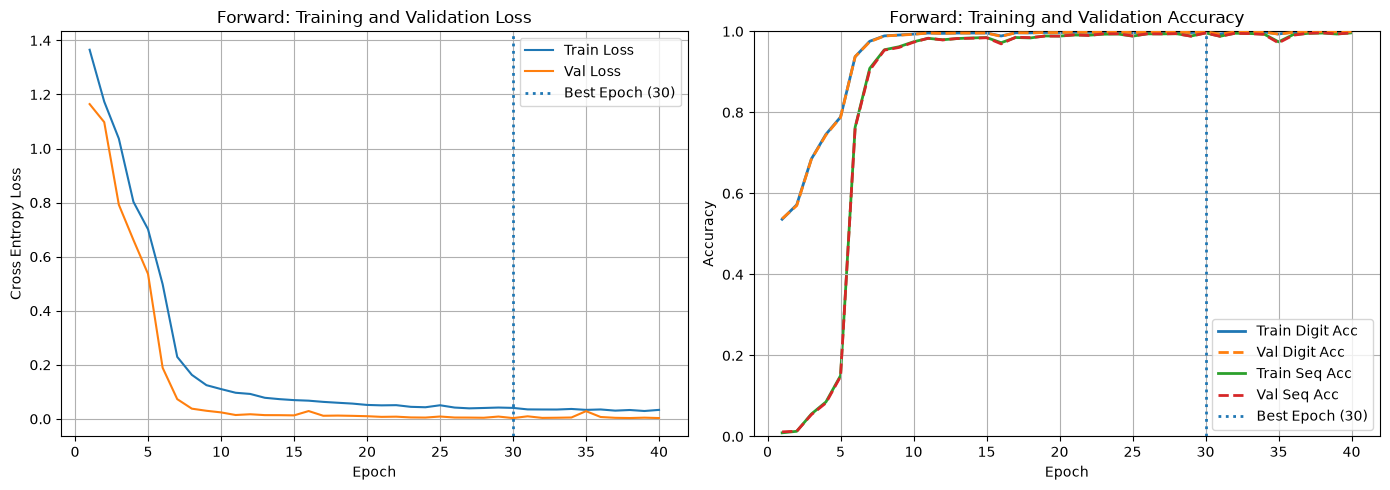

In [28]:
# create the training and validation plots
fig,axes = plt.subplots(1,2,figsize=(14,5))

epochs_plot = range(1,len(train_losses4disp)+1)

# plot the training and validation loss
axes[0].plot(epochs_plot,train_losses4disp,label='Train Loss')
axes[0].plot(epochs_plot,test_losses4disp,label='Val Loss')
axes[0].axvline(best_epoch,linestyle=':',linewidth=2,label=f'Best Epoch ({best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross Entropy Loss')
axes[0].set_title('Forward: Training and Validation Loss')
axes[0].grid(True)
axes[0].legend()

# plot the training and validation accuracies
axes[1].plot(epochs_plot,train_digit_accuracy4disp,'-',linewidth=2,zorder=1,label='Train Digit Acc')
axes[1].plot(epochs_plot,test_digit_accuracy4disp,'--',linewidth=2,zorder=3,label='Val Digit Acc')
axes[1].plot(epochs_plot,train_seq_accuracy4disp,'-',linewidth=2,zorder=1,label='Train Seq Acc')
axes[1].plot(epochs_plot,test_seq_accuracy4disp,'--',linewidth=2,zorder=3,label='Val Seq Acc')
axes[1].axvline(best_epoch,linestyle=':',linewidth=2,label=f'Best Epoch ({best_epoch})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Forward: Training and Validation Accuracy')
axes[1].set_ylim((0,1))
axes[1].grid(True)
axes[1].legend()

# save and display the plots
plt.tight_layout()
plt.savefig('plot/training_curves_forward.png')
plt.show()

## Final Model Training
The best epoch was selected using early stopping, and the model was then retrained on the combined training and validation datasets for the selected number of epochs.

In [16]:
# combine the training and validation datasets
data_final_train = data_train + data_val

# reset the seed before creating the final model
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# reset the model
model = TransformerModel(
    ntoken=tokenizer.ntokens,
    ninp=128,
    nhead=16,
    nhid=64,
    nlayers=6
).to(device)

# reset the optimizer
optimizer = torch.optim.AdamW(model.parameters(),lr=learning_rate)

/tmp/ipykernel_1366/644045642.py:38: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layers,nlayers)


In [17]:
# train the final model using the combined train and validation dataset
for epoch in range(1,best_epoch+1):
    model.train()

    total_loss = 0.
    n_batch = 0
    iterable = range(0,len(data_final_train),batch_size)

    for batch,i in tqdm(enumerate(iterable),total=len(iterable),colour='GREEN'):
        n_batch += 1

        # get a training batch
        prompts,target_answers,length_prompts,length_answers = get_batch(data_final_train,i,batch_size,tokenizer)
        prompts = prompts.to(device)
        target_answers = target_answers.to(device)
        input_tensor = torch.cat((prompts,target_answers),0)

        optimizer.zero_grad()

        # predict the next token
        output,_,_ = model(input_tensor)
        output_answers = output[length_prompts-1:-1,:,:].reshape(-1,tokenizer.ntokens)
        target_answers = target_answers.view(-1)

        # calculate the loss
        loss = criterion(output_answers,target_answers)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    total_loss /= n_batch

    print('Epoch {:3d}/{:3d}, loss:{:7.5f}'.format(
        epoch,best_epoch,total_loss
    ))

100%|██████████| 1200/1200 [00:51<00:00, 23.27it/s]


Epoch   1/ 30, loss:1.33267


100%|██████████| 1200/1200 [00:51<00:00, 23.36it/s]


Epoch   2/ 30, loss:1.15725


100%|██████████| 1200/1200 [00:51<00:00, 23.15it/s]


...

Epoch  28/ 30, loss:0.03586


100%|██████████| 1200/1200 [00:51<00:00, 23.49it/s]


Epoch  29/ 30, loss:0.03692


100%|██████████| 1200/1200 [00:51<00:00, 23.15it/s]

Epoch  30/ 30, loss:0.03617


In [18]:
# save the final forward model
torch.save(model.state_dict(),"assets/forward_model.pth")
print("Final forward model saved to assets/forward_model.pth")

Final forward model saved to assets/forward_model.pth
